## Problem 9.3 - Kernelized SVM

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from matplotlib.colors import LinearSegmentedColormap

In [11]:
# truncate the colormap RdPu (I just do that for aesthetic reasons)
truncated_RdPu = LinearSegmentedColormap.from_list('truncated_RdPu', plt.cm.RdPu(np.linspace(0.3, 0.8, 100))) 

In [12]:
X, y = make_moons(n_samples = 200, noise = 0.15, random_state = 42)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 0)

### (i) Train SVM classifier with different kernels

In [13]:
kernels = ['linear', 'poly', 'rbf']

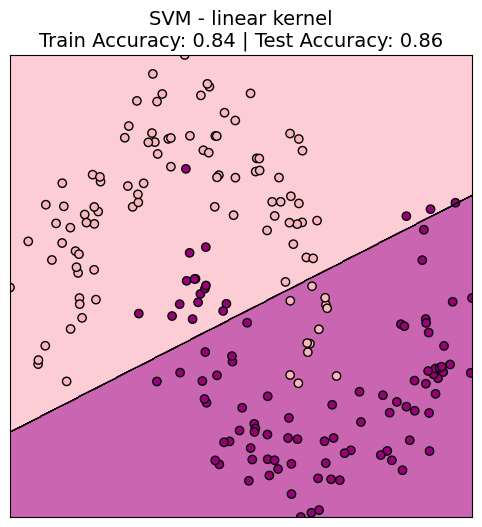

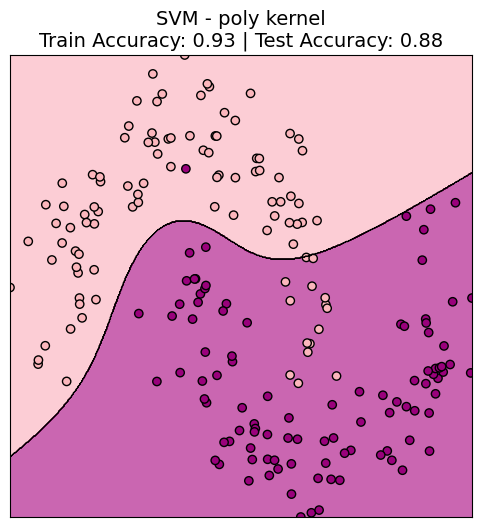

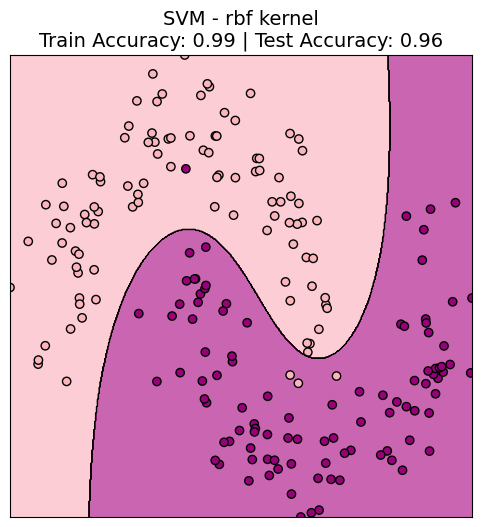

In [ ]:
for kernel in kernels:
    svm = SVC(kernel=kernel, degree = 3)
    svm.fit(X_train, y_train)

    svm_train_accuracy = svm.score(X_train, y_train)
    svm_test_accuracy  = svm.score(X_test, y_test)

    fig = plt.figure(figsize = (8, 6))
    ax = fig.add_subplot()
    x0, x1 = np.meshgrid(
        np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
        np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
    )
    x_new = np.c_[x0.ravel(), x1.ravel()]
    y_pred = svm.predict(x_new)
    zz = svm.decision_function(x_new).reshape(x0.shape)

    plt.contourf(x0, x1, zz, alpha = 0.6, cmap = truncated_RdPu)
    plt.contour(x0, x1, zz, colors = ['black'], linewidths = [0.4])
    plt.scatter(X[:,0], X[:,1], c = y, edgecolors = 'k', cmap = truncated_RdPu)
    ax.set_title(
            f"SVM - {kernel} kernel\n"
            f"Train Accuracy: {svm_train_accuracy:.2f} | "
            f"Test Accuracy: {svm_test_accuracy:.2f}",
            fontsize = 14
        )
    ax.set_box_aspect(1)
    ax.xaxis.set_tick_params(labelbottom = False)
    ax.yaxis.set_tick_params(labelleft = False)
    ax.set_xticks([])
    ax.set_yticks([])

In [34]:
from sklearn import svm
from sklearn.inspection import DecisionBoundaryDisplay

# INFORMATION: This function has been taken from the website linked on the exercise sheet
def plot_training_data_with_decision_boundary(
    kernel, ax = None, long_title = True, support_vectors = True
):
    # Train the SVC
    clf = svm.SVC(kernel = kernel, gamma = 2).fit(X, y)

    # Settings for plotting
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    x_min, x_max, y_min, y_max = -3, 3, -3, 3
    ax.set(xlim=(x_min, x_max), ylim=(y_min, y_max))

    # Plot decision boundary and margins
    common_params = {"estimator": clf, "X": X, "ax": ax}
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="predict",
        plot_method="pcolormesh",
        alpha=0.3,
    )
    DecisionBoundaryDisplay.from_estimator(
        **common_params,
        response_method="decision_function",
        plot_method="contour",
        levels=[-1, 0, 1],
        colors=["k", "k", "k"],
        linestyles=["--", "-", "--"],
    )

    if support_vectors:
        # Plot bigger circles around samples that serve as support vectors
        ax.scatter(
            clf.support_vectors_[:, 0],
            clf.support_vectors_[:, 1],
            s=150,
            facecolors = "none",
            edgecolors = "k",
        )

    # Plot samples by color and add legend
    scatter = ax.scatter(X[:, 0], X[:, 1], c = y, s = 30, edgecolors = "k")
    ax.legend(*scatter.legend_elements(), loc = "upper right", title = "Classes")
    if long_title:
        ax.set_title(f" Decision boundaries of {kernel} kernel in SVC")
    else:
        ax.set_title(kernel)

    if ax is None:
        plt.show()

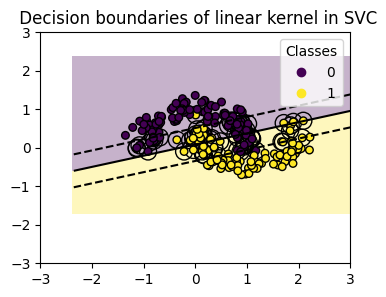

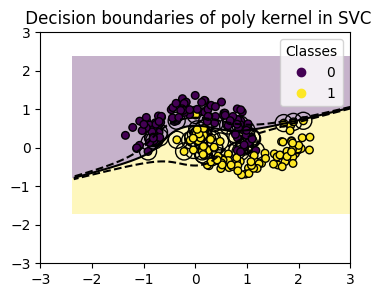

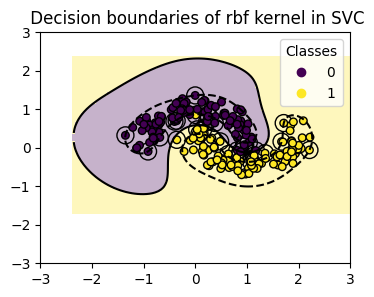

In [36]:
for kernel in kernels:
    plot_training_data_with_decision_boundary(kernel)

### (ii) Test SVM with rbf-kernel for different (C, γ)

In [21]:
C_vals = [0.1, 1, 100]
gamma_vals = [0.1, 1, 10]

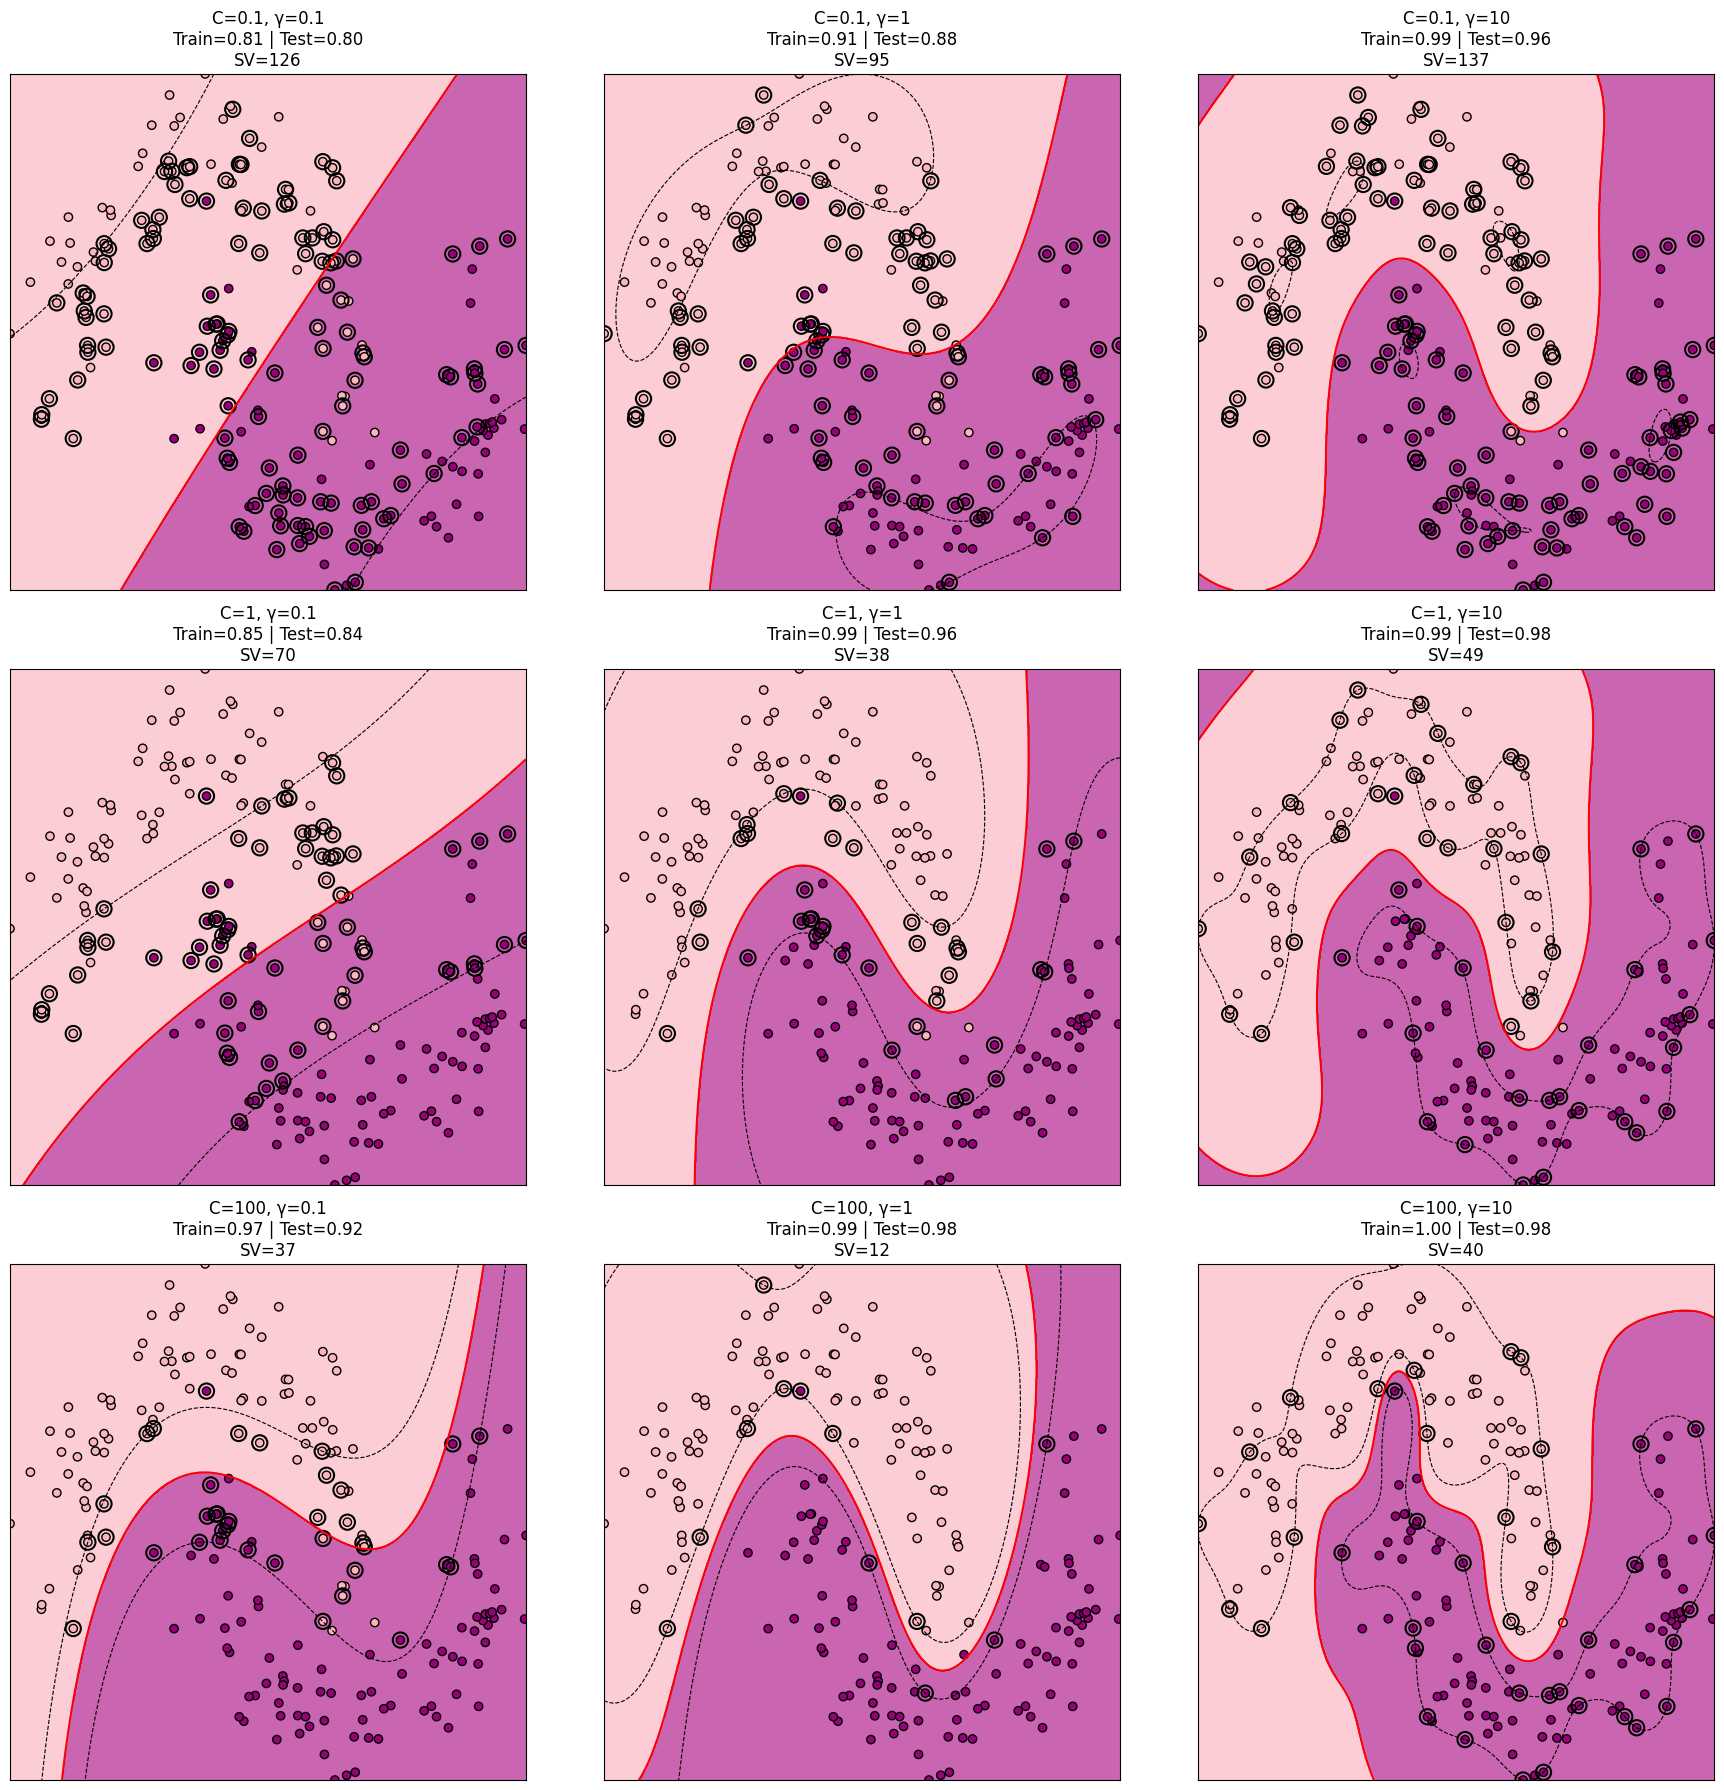

In [20]:
C_vals = [0.1, 1, 100]
gamma_vals = [0.1, 1, 10]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for i, C in enumerate(C_vals):
    for j, gamma in enumerate(gamma_vals):

        # Train SVM
        svm = SVC(kernel='rbf', C=C, gamma=gamma)
        svm.fit(X_train, y_train)

        train_acc = svm.score(X_train, y_train)
        test_acc  = svm.score(X_test, y_test)
        n_sv = len(svm.support_vectors_)

        ax = axes[i, j]

        # Grid
        x0, x1 = np.meshgrid(
            np.linspace(X[:,0].min(), X[:,0].max(), 500).reshape(-1, 1),
            np.linspace(X[:,1].min(), X[:,1].max(), 500).reshape(-1, 1)
        )
        x_new = np.c_[x0.ravel(), x1.ravel()]

        # Decision function for DB + margins
        zz = svm.decision_function(x_new).reshape(x0.shape)

        # Class predictions for region coloring
        y_pred = svm.predict(x_new).reshape(x0.shape)

        # Filled decision regions
        ax.contourf(x0, x1, y_pred, alpha=0.6, cmap=truncated_RdPu)

        # Decision boundary (0) and margins (±1)
        ax.contour(x0, x1, zz,
                   levels=[-1, 0, 1],
                   colors=['black', 'red', 'black'],
                   linewidths=[0.8, 1.4, 0.8],
                   linestyles=['--', '-', '--'])

        # Data points
        ax.scatter(X[:,0], X[:,1], c=y, edgecolors='k', cmap=truncated_RdPu)

        # Support vectors
        ax.scatter(svm.support_vectors_[:,0],
                   svm.support_vectors_[:,1],
                   s=120, facecolors='none', edgecolors='black', linewidths=1.5)

        # Title
        ax.set_title(
            f"C={C}, γ={gamma}\n"
            f"Train={train_acc:.2f} | Test={test_acc:.2f}\n"
            f"SV={n_sv}",
            fontsize=12
        )

        # Axis formatting
        ax.set_box_aspect(1)
        ax.set_xticks([])
        ax.set_yticks([])

plt.tight_layout()
plt.show()